In [31]:
import pandas as pd
from fastai.vision.all import *
import regex as re

In [32]:
df = pd.read_csv(r'D:\Traffic\labels_processed.csv')

In [33]:
df2 = pd.read_csv(r'D:\Traffic\test_csv.csv')

In [34]:
fname = Path(r'D:\Traffic\traffic_Data_processed\DATA\26\26_21.png')

In [35]:
class_name = re.findall(r'(\d+)_.*\.png$', fname.name)
class_id = int(class_name[0])
real_id = int(df2['New'][class_id])
real_id

24

In [37]:
df["Names"][real_id]

'keep Right'

In [38]:
df['Names'][3]

'Speed limit (40km/h)'

In [39]:
def label_function(dpath):
    class_name = re.findall(r'(\d+)_.*\.png$', dpath.name)
    class_id = int(class_name[0])
    return df['Names'][class_id]

In [40]:
label_function(fname)

'watch out for cars'

In [41]:
signs = DataBlock(blocks = (ImageBlock, CategoryBlock),
                  get_items = get_image_files,
                  splitter = RandomSplitter(seed = 42),
                  get_y = label_function,
                  item_tfms = Resize(224),
                  batch_tfms = aug_transforms(size = 224, min_scale = 0.75, do_flip = False))

In [42]:
path = Path(r'D:\Traffic\traffic_Data_processed\DATA')

In [43]:
dls = signs.dataloaders(path)

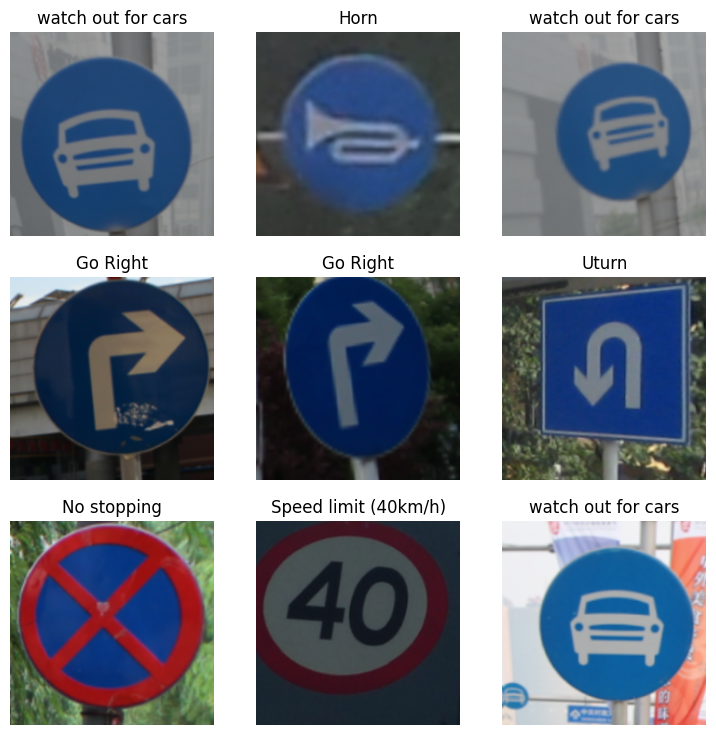

In [44]:
dls.show_batch()

In [45]:
model_1 = vision_learner(dls, arch = resnet34, metrics = error_rate)

<div></div>

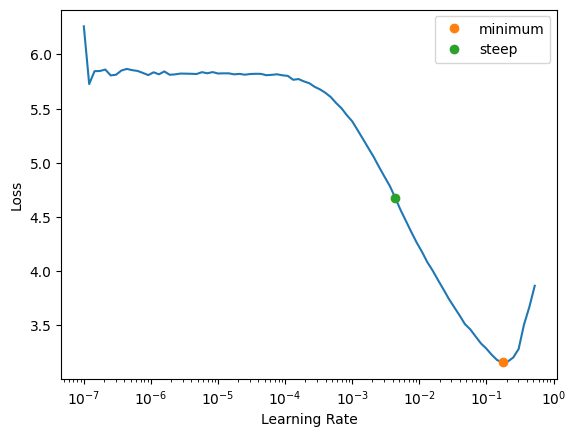

In [46]:
lr_min, lr_steep = model_1.lr_find(suggest_funcs=(minimum,steep))

In [47]:
lr_min, lr_steep

(0.017378008365631102, 0.004365158267319202)

In [48]:
lr_min_1 = lr_min
lr_steep_1 = lr_steep

In [50]:
model_1_1_1 = vision_learner(dls, arch = resnet34, metrics = error_rate)
model_1_1_1.fit_one_cycle(3, lr_steep_1/4)

epoch,train_loss,valid_loss,error_rate,time
0,2.663481,0.504146,0.126506,01:53
1,1.040534,0.180366,0.048193,00:22
2,0.532380,0.149028,0.043373,00:23


In [51]:
model_1_1_2 = vision_learner(dls, arch = resnet34, metrics = error_rate)
model_1_1_2.fit_one_cycle(3, lr_min_1/10)

epoch,train_loss,valid_loss,error_rate,time
0,2.178471,0.369688,0.096386,00:27
1,0.807552,0.112772,0.037349,00:23
2,0.368423,0.098249,0.025301,00:23


In [52]:
model_1_1_3 = vision_learner(dls, arch = resnet34, metrics = error_rate)
model_1_1_3.fit_one_cycle(3, lr_min_1/100)

epoch,train_loss,valid_loss,error_rate,time
0,4.736996,2.242846,0.525301,00:23
1,2.908378,1.229174,0.303614,00:23
2,2.123796,1.121756,0.272289,00:22


epoch,train_loss,valid_loss,error_rate,time
0,2.179221,0.360230,0.098795,00:19
1,0.804348,0.113539,0.025301,00:19
2,0.373694,0.089248,0.021687,00:19


<div></div>

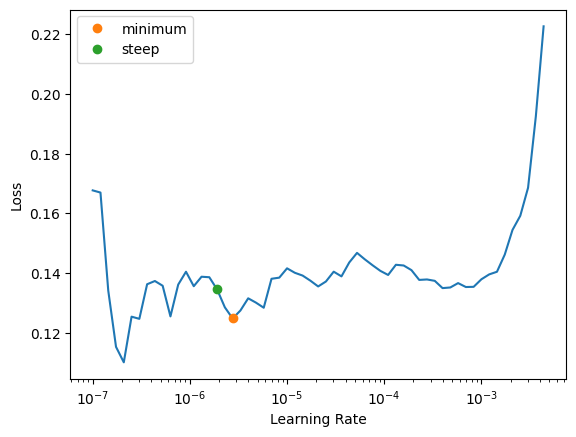

In [55]:
model_1_2_0 = vision_learner(dls, arch = resnet34, metrics = error_rate)
model_1_2_0.fit_one_cycle(3, lr_min_1/10)
model_1_2_0.unfreeze()
lr_min_1_2, lr_steep_1_2 = model_1_2_0.lr_find(suggest_funcs=(minimum,steep))

Here in the 3rd head epoch the error rate increased and so deleted the whole cell and then started again and then error rate decreased as usual in 3rd head epoch

this can happen due to mini_batch randomness, random initialization of the head(random weights of the last layer unless you specigy the random seed) or data augmentation  
so thsi can be soolved by random seed and so i will set random seed before each experiment

In [56]:
set_seed(42, reproducible = True)

In [57]:
lr_min_1_2, lr_steep_1_2

(2.7542287170945203e-07, 1.9054607491852948e-06)

In [60]:
model_1_2_1 = vision_learner(dls, arch = resnet34, metrics = error_rate)
model_1_2_1.fit_one_cycle(3, lr_min_1/10)
model_1_2_1.unfreeze()
model_1_2_1.fit_one_cycle(12, lr_max = slice(lr_steep_1_2/10, lr_steep_1_2/4))

epoch,train_loss,valid_loss,error_rate,time
0,2.172478,0.305113,0.090361,00:19
1,0.783036,0.085516,0.024096,00:18
2,0.352717,0.065535,0.015663,00:18


epoch,train_loss,valid_loss,error_rate,time
0,0.128720,0.065274,0.018072,00:23
1,0.129835,0.063646,0.018072,00:23
2,0.136062,0.064865,0.020482,00:23
3,0.134553,0.061248,0.016867,00:23
4,0.128219,0.060625,0.014458,00:23
5,0.128637,0.060924,0.016867,00:23
6,0.123460,0.058208,0.015663,00:23
7,0.115411,0.058664,0.013253,00:35
8,0.123279,0.058414,0.014458,00:30
9,0.131472,0.058386,0.014458,00:23


As we can see that our error rate is fluctuating , like increasing adn then decreasing and then again increasing and so on so this is completely normal and overall it is good run

In [61]:
model_1_2_2 = vision_learner(dls, arch = resnet34, metrics = error_rate)
model_1_2_2.fit_one_cycle(3, lr_min_1/10)
model_1_2_2.unfreeze()
model_1_2_2.fit_one_cycle(12, lr_max = slice(lr_steep_1_2/4, lr_min_1_2/10))

epoch,train_loss,valid_loss,error_rate,time
0,2.133999,0.351577,0.119277,00:19
1,0.778463,0.110790,0.042169,00:19
2,0.368115,0.079156,0.027711,00:19


epoch,train_loss,valid_loss,error_rate,time
0,0.148656,0.079211,0.026506,00:23
1,0.148289,0.084349,0.032530,00:23
2,0.149795,0.078863,0.027711,00:23
3,0.142522,0.077624,0.027711,00:23
4,0.133520,0.077541,0.026506,00:23
5,0.138986,0.073708,0.025301,00:23
6,0.137353,0.073044,0.024096,00:23
7,0.134226,0.078122,0.028916,00:23
8,0.131074,0.072741,0.025301,00:23
9,0.139638,0.077558,0.027711,00:23


In [62]:
model_1_2_3 = vision_learner(dls, arch = resnet34, metrics = error_rate)
model_1_2_3.fit_one_cycle(3, lr_min_1/10)
model_1_2_3.unfreeze()
model_1_2_3.fit_one_cycle(12, lr_max = slice(lr_min_1_2/10, lr_min_1_2/100))

epoch,train_loss,valid_loss,error_rate,time
0,2.158150,0.305227,0.081928,00:19
1,0.777213,0.115390,0.028916,00:19
2,0.349278,0.080958,0.022892,00:19


epoch,train_loss,valid_loss,error_rate,time
0,0.132745,0.085255,0.022892,00:23
1,0.145532,0.084432,0.022892,00:23
2,0.143576,0.083207,0.022892,00:23
3,0.132865,0.081803,0.022892,00:23
4,0.132189,0.081031,0.024096,00:23
5,0.130837,0.084065,0.025301,00:23
6,0.129844,0.081387,0.024096,00:23
7,0.138533,0.084427,0.024096,00:23
8,0.134811,0.084997,0.022892,00:23
9,0.126859,0.084135,0.024096,00:23


As you can see that the first lr range was the best and so we have chosen that as the lr for the whole model along with the lr_min_1/10 for training head